Status: exploratory

# Boundary effects in spatial-domain (Leiden) clustering\n\nFollows the sc-best-practices.org spatial-domains tutorial's \"combined graph\" recipe (expression-neighbor graph + spatial-neighbor graph, joint Leiden), then asks: does a `bosperrus`-style border-effect correction of the PCA embedding (as a function of distance to the nearest border spot) change the resulting clusters, and does that change count as an *improvement*?\n\n- **Reads:** `sq.datasets.visium_hne_adata()` (squidpy's bundled adult mouse brain Visium demo, ~2700 spots; ships with an approximate ground-truth `cluster` annotation from the original 10x/squidpy processing — not manual pathologist ground truth, but a reasonable proxy for evaluation).\n- **Writes:** `../../results/exploratory/boundary_effects_clustering/` (fit_quality.csv, ground_truth_concordance.csv, concordance_by_distance_bin.csv, boundary_signal_diagnostic.csv, distance_by_cluster_boxplot.svg).\n- **Runtime:** a few minutes on this small demo dataset.\n\n**Border-spot definition:** a spot is a border spot if it has fewer than 6 neighbors in the Visium hex-grid spatial graph — this also flags spots adjacent to internal tissue holes/folds, not just the outer capture-area perimeter, which is the correct generalization of \"fewer neighbours = boundary artifact\" from the bosperrus paper's centrality-measure setting."


In [1]:
%load_ext autoreload
%autoreload 2

import pathlib

import numpy as np
import pandas as pd
import scanpy as sc
import squidpy as sq
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kruskal
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    homogeneity_completeness_v_measure,
)

from bosperrus import Flow
from bosperrus.distances import distance_to_pointset

sc.settings.verbosity = 1
sc.settings.set_figure_params(dpi=80, facecolor="white")

RNG_SEED = 0
N_PCS = 30
ALPHA = 0.2  # weight of the spatial graph in the joint graph, matches the tutorial's example
N_DISTANCE_BINS = 4

OUT_DIR = pathlib.Path("../../results/exploratory/boundary_effects_clustering")
OUT_DIR.mkdir(parents=True, exist_ok=True)

/home/woody/iwbn/iwbn007h/bosperrus/truncated_graphs/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/tmp/ipykernel_67443/3934932758.py:23: FutureWarning: Use `scanpy.set_figure_params` instead
  sc.settings.set_figure_params(dpi=80, facecolor="white")


## 1. Load data + baseline joint-graph clustering (no correction)\n\nReplicates `spatial_domains.ipynb`'s combined-graph recipe: expression-neighbor graph + Visium hex-grid spatial-neighbor graph, joint Leiden. This is the \"before correction\" baseline everything else compares against.

In [2]:
adata = sq.datasets.visium_hne_adata()

if "X_pca" not in adata.obsm or adata.obsm["X_pca"].shape[1] < N_PCS:
    sc.pp.pca(adata, n_comps=N_PCS, random_state=RNG_SEED)

sc.pp.neighbors(adata, n_pcs=N_PCS, random_state=RNG_SEED)
nn_graph_genes = adata.obsp["connectivities"]

sq.gr.spatial_neighbors(adata, coord_type="grid", n_neighs=6)
nn_graph_space = adata.obsp["spatial_connectivities"]

joint_graph_before = (1 - ALPHA) * nn_graph_genes + ALPHA * nn_graph_space
sc.tl.leiden(adata, adjacency=joint_graph_before, key_added="leiden_before", random_state=RNG_SEED)

print(adata.obs["leiden_before"].value_counts())

INFO     Creating graph using `None` transform and `1` libraries.                                                  


/tmp/ipykernel_67443/1312264605.py:9: FutureWarning: Calling `spatial_neighbors` is deprecated and will be removed in squidpy v1.9.0. Use `spatial_neighbors_knn`, `spatial_neighbors_radius`, `spatial_neighbors_delaunay`, `spatial_neighbors_grid`, or `spatial_neighbors_from_builder` instead.
  sq.gr.spatial_neighbors(adata, coord_type="grid", n_neighs=6)
/tmp/ipykernel_67443/1312264605.py:13: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, adjacency=joint_graph_before, key_added="leiden_before", random_state=RNG_SEED)


leiden_before
0     311
1     258
2     233
3     217
4     212
5     189
6     173
7     171
8     148
9     147
10    131
11    109
12    105
13     97
14     94
15     93
Name: count, dtype: int64


## 2. Border-spot detection + distance to nearest border spot\n\nA spot is a border spot if its degree in the hex-grid spatial graph is < 6 (fewer than the full complement of hex neighbors — either at the outer tissue edge or next to an internal hole/fold). Distance is then computed with the existing `bosperrus.distances.distance_to_pointset` — nearest-neighbor distance to that set of border-spot coordinates.

In [3]:
spatial_degree = np.asarray((nn_graph_space > 0).sum(axis=1)).ravel()
is_border_spot = spatial_degree < 6

coords = adata.obsm["spatial"]
border_coords = coords[is_border_spot]

dist_to_border = distance_to_pointset(coords, border_coords)
adata.obs["distance_to_border"] = dist_to_border.values
adata.obs["is_border_spot"] = is_border_spot

print(f"{is_border_spot.sum()} / {adata.n_obs} spots ({is_border_spot.mean():.1%}) flagged as border spots (spatial degree < 6)")
adata.obs["distance_to_border"].describe()

281 / 2688 spots (10.5%) flagged as border spots (spatial degree < 6)


count    2688.000000
mean      638.054406
std       476.847514
min         0.000000
25%       239.000000
50%       552.327801
75%       964.580735
max      1867.126134
Name: distance_to_border, dtype: float64

## 3. BOSPERRUS correction of the top PCs\n\nRather than correcting per-gene (thousands of noisy independent fits), each of the top `N_PCS` principal components is treated as a `bosperrus` \"score\" and fit against `distance_to_border`, exactly like the package already does for centrality measures — `ConstantFit`/`PiecewiseLinearFit`/`ExponentialSaturationFit`/`MichaelisMentenFit`, AIC-selected, additively corrected toward the fitted plateau. `flow.flow()` is called with no keyword arguments so this cell works whether the environment resolves the currently-installed PyPI `bosperrus` (`measures=`/`calculate_rel_ll_to_baseline=`) or the in-progress rename (`score_names=`/`baseline_fit_class=`) — both accept the all-defaults call.

In [4]:
pc_cols = [f"PC{i}" for i in range(N_PCS)]
# NOTE: deliberately NOT using index=adata.obs_names here. bosperrus.pipeline.Flow.flow()
# currently mishandles a non-default index: Fit._expand_to_original_index() always rebuilds
# a fresh range(len(...)) index internally, and Flow.flow()'s `self.observations[col] = best_fit.S_corrected`
# assignment then label-aligns against flow.observations' *original* index -- with a string
# (e.g. obs_names) index none of the labels match and every corrected column silently comes back
# all-NaN (confirmed with a minimal repro outside this notebook; reported upstream). Using the
# default RangeIndex here keeps both sides aligned; row order is preserved throughout so it's
# safe to reattach adata.obs_names positionally afterwards.
pcs_df = pd.DataFrame(adata.obsm["X_pca"][:, :N_PCS], columns=pc_cols)
distances_series = pd.Series(adata.obs["distance_to_border"].values, name="distance_to_border")

flow = Flow.from_distances_and_scores(distances=distances_series, scores=pcs_df)
flow.flow()

fit_quality = flow.fit_quality.T[["best_fit_type", "observed_effect_strength", "observed_half_life", "affected samples"]]
fit_quality.to_csv(OUT_DIR / "fit_quality.csv")
fit_quality

,best_fit_type,observed_effect_strength,observed_half_life,affected samples
PC0,Piecewise Linear Fit,-3.159181,0.5,0.999628
PC1,Piecewise Linear Fit,-3.18209,0.49833,0.999628
PC2,Piecewise Linear Fit,-3.995072,0.455188,0.985491
PC3,Michaelis-Menten Fit,2.783041,0.109179,1.0
PC4,Constant Fit,0,0,0.0
PC5,Piecewise Linear Fit,1.361901,0.051367,0.204985
PC6,Piecewise Linear Fit,-7.615127,0.385391,0.921131
PC7,Michaelis-Menten Fit,-6.412211,0.380815,1.0
PC8,Piecewise Linear Fit,3.153992,0.191855,0.610491
PC9,Piecewise Linear Fit,-27.720029,0.336308,0.863095


In [5]:
corrected_cols = [f"BOSPERRUS corrected {c}" for c in pc_cols]
adata.obsm["X_pca_corrected"] = flow.observations[corrected_cols].values

n_constant = (fit_quality["best_fit_type"] == "Constant Fit").sum()
print(f"{n_constant} / {N_PCS} PCs selected the null (Constant Fit) model — i.e. no detectable boundary effect")

4 / 30 PCs selected the null (Constant Fit) model — i.e. no detectable boundary effect


## 4. Rebuild the joint graph from corrected PCs, re-cluster\n\nSame recipe as step 1 (same `ALPHA`, same spatial graph), but the expression-neighbor graph is now built on `X_pca_corrected` instead of `X_pca`.

In [6]:
sc.pp.neighbors(adata, use_rep="X_pca_corrected", key_added="corrected", random_state=RNG_SEED)
nn_graph_genes_corrected = adata.obsp["corrected_connectivities"]

joint_graph_after = (1 - ALPHA) * nn_graph_genes_corrected + ALPHA * nn_graph_space
sc.tl.leiden(adata, adjacency=joint_graph_after, key_added="leiden_after", random_state=RNG_SEED)

print(adata.obs["leiden_after"].value_counts())
print(f"\nn_clusters before={adata.obs['leiden_before'].nunique()}, after={adata.obs['leiden_after'].nunique()}")
print("(cluster *count* differs between runs at fixed resolution regardless of correction quality; "
      "keep this in mind when reading the metrics below rather than assuming a like-for-like partition size.)")

/tmp/ipykernel_67443/1637755175.py:5: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, adjacency=joint_graph_after, key_added="leiden_after", random_state=RNG_SEED)


leiden_after
0     311
1     282
2     268
3     262
4     251
5     235
6     208
7     183
8     153
9     145
10    124
11    102
12     74
13     60
14     30
Name: count, dtype: int64

n_clusters before=16, after=15
(cluster *count* differs between runs at fixed resolution regardless of correction quality; keep this in mind when reading the metrics below rather than assuming a like-for-like partition size.)


## 5. Evaluation — did clustering improve?\n\nTwo independent families of evidence, since only one of them needs a ground truth:\n\n**(a) Boundary-signal diagnostic (no ground truth needed).** If clusters were partly artifacts of \"this spot happens to be near the tissue edge\", cluster identity should statistically associate with `distance_to_border`. A Kruskal-Wallis test + eta-squared effect size quantifies that association before vs. after — a real correction should shrink it.\n\n**(b) Ground-truth concordance (needs the `cluster` annotation).** ARI / NMI / homogeneity / completeness / V-measure against `adata.obs[\"cluster\"]`, computed overall *and* stratified by distance-to-border quartile. The overall numbers can move for reasons unrelated to the border (e.g. resolution differences), so the stratified breakdown is the sharper test: a genuine border-effect correction should show its largest concordance gain in the nearest-to-border quartile (Q1), tapering off toward the interior (Q4) — a uniform gain across all quartiles would suggest the correction is just perturbing the embedding generally, not fixing a boundary-specific artifact.

In [7]:
def cluster_distance_association(cluster_labels, distances):
    """Kruskal-Wallis association between cluster identity and distance-to-border,
    plus its eta-squared effect size: (H - k + 1) / (n - k)."""
    groups = [distances[cluster_labels == c] for c in pd.unique(cluster_labels)]
    stat, p = kruskal(*groups)
    k, n = len(groups), len(distances)
    eta_sq = (stat - k + 1) / (n - k)
    return stat, p, eta_sq

h_before, p_before, eta_before = cluster_distance_association(
    adata.obs["leiden_before"].values, adata.obs["distance_to_border"].values
)
h_after, p_after, eta_after = cluster_distance_association(
    adata.obs["leiden_after"].values, adata.obs["distance_to_border"].values
)

boundary_signal = pd.DataFrame(
    {"before_correction": [h_before, p_before, eta_before], "after_correction": [h_after, p_after, eta_after]},
    index=["kruskal_H", "p_value", "eta_squared"],
)
boundary_signal.to_csv(OUT_DIR / "boundary_signal_diagnostic.csv")
boundary_signal

,before_correction,after_correction
kruskal_H,1.359617e+03,8.592737e+02
p_value,8.045112e-281,2.282746e-174
eta_squared,5.032248e-01,3.162266e-01


In [8]:
def concordance(true_labels, pred_labels):
    hom, comp, vmeas = homogeneity_completeness_v_measure(true_labels, pred_labels)
    return {
        "ARI": adjusted_rand_score(true_labels, pred_labels),
        "NMI": normalized_mutual_info_score(true_labels, pred_labels),
        "homogeneity": hom,
        "completeness": comp,
        "v_measure": vmeas,
    }

ground_truth = adata.obs["cluster"].values
metrics_before = concordance(ground_truth, adata.obs["leiden_before"].values)
metrics_after = concordance(ground_truth, adata.obs["leiden_after"].values)

comparison = pd.DataFrame({"before_correction": metrics_before, "after_correction": metrics_after})
comparison["delta"] = comparison["after_correction"] - comparison["before_correction"]
comparison.to_csv(OUT_DIR / "ground_truth_concordance.csv")
comparison

,before_correction,after_correction,delta
ARI,0.731835,0.719137,-0.012698
NMI,0.832403,0.821110,-0.011293
homogeneity,0.845855,0.814716,-0.031138
completeness,0.819373,0.827605,0.008233
v_measure,0.832403,0.821110,-0.011293


In [9]:
adata.obs["distance_bin"] = pd.qcut(
    adata.obs["distance_to_border"], N_DISTANCE_BINS, labels=[f"Q{i+1}_of_{N_DISTANCE_BINS}" for i in range(N_DISTANCE_BINS)]
)  # Q1 = closest to a border spot, Q{N} = deepest in the tissue interior

rows = []
for b in adata.obs["distance_bin"].cat.categories:
    mask = (adata.obs["distance_bin"] == b).values
    m_before = concordance(ground_truth[mask], adata.obs["leiden_before"].values[mask])
    m_after = concordance(ground_truth[mask], adata.obs["leiden_after"].values[mask])
    rows.append({
        "distance_bin": b,
        "n_spots": int(mask.sum()),
        "ARI_before": m_before["ARI"], "ARI_after": m_after["ARI"], "ARI_delta": m_after["ARI"] - m_before["ARI"],
        "NMI_before": m_before["NMI"], "NMI_after": m_after["NMI"], "NMI_delta": m_after["NMI"] - m_before["NMI"],
    })

stratified = pd.DataFrame(rows)
stratified.to_csv(OUT_DIR / "concordance_by_distance_bin.csv", index=False)
stratified

,distance_bin,n_spots,ARI_before,ARI_after,ARI_delta,NMI_before,NMI_after,NMI_delta
0,Q1_of_4,682,0.616406,0.667688,0.051282,0.778233,0.803686,0.025453
1,Q2_of_4,676,0.785199,0.763779,-0.021420,0.854547,0.852374,-0.002173
2,Q3_of_4,658,0.875579,0.848652,-0.026927,0.896291,0.885320,-0.010971
3,Q4_of_4,672,0.836933,0.803242,-0.033690,0.897064,0.861404,-0.035660


## 6. Visualization\n\nSpatial maps (ground truth vs. before vs. after) and, for each clustering, a boxplot of `distance_to_border` per cluster — a cluster that's mostly a thin rim hugging the tissue edge should show up as a box sitting much lower than the others, and that box should either vanish or rise toward the rest after correction.

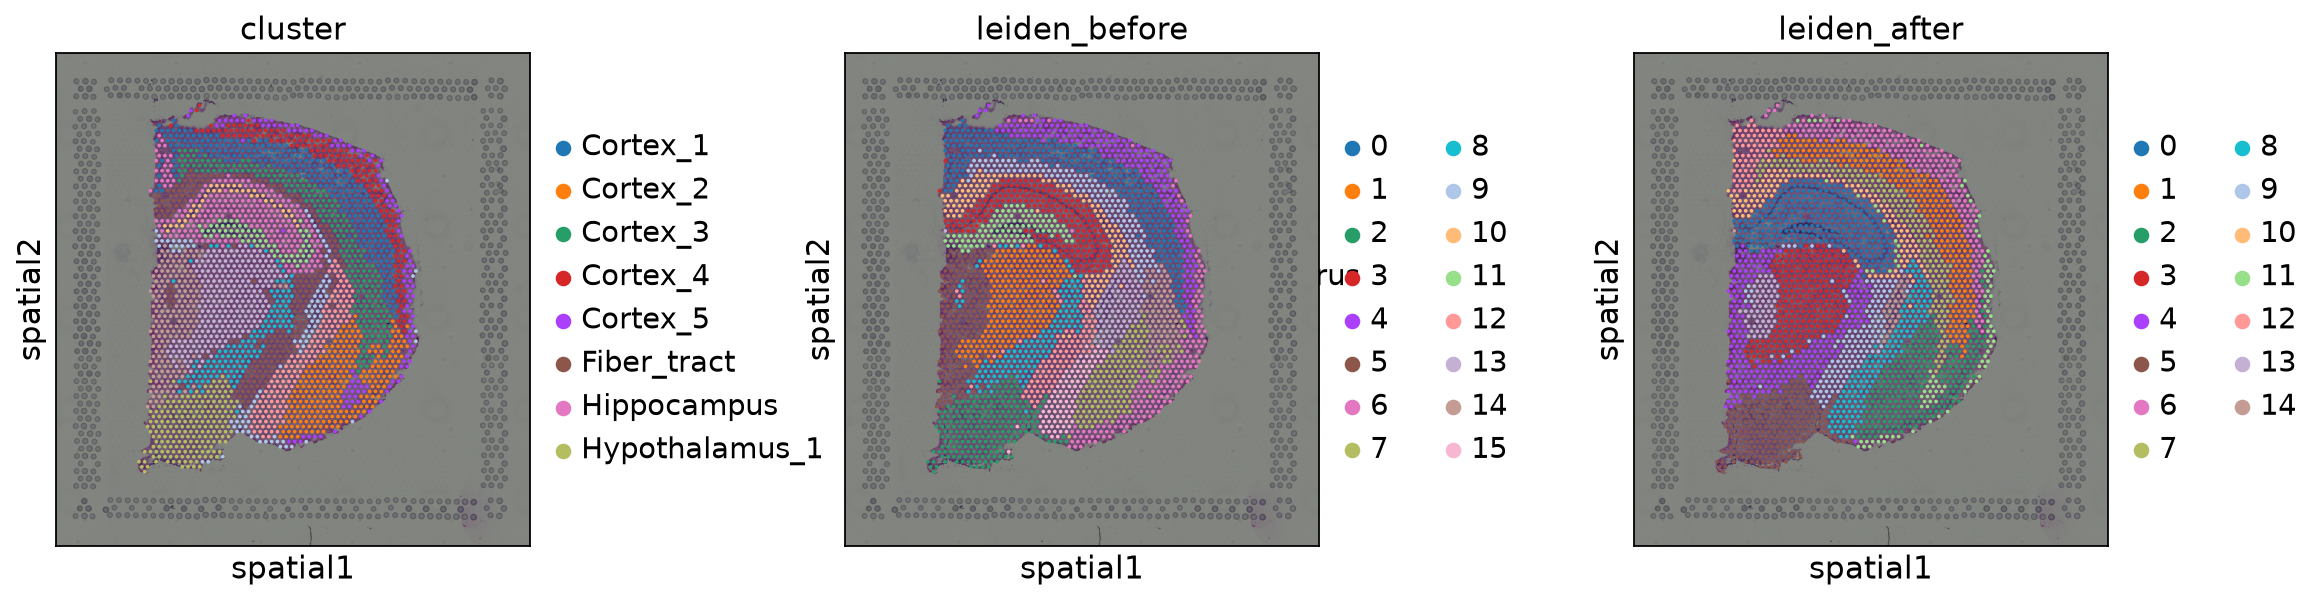

In [10]:
sq.pl.spatial_scatter(adata, color=["cluster", "leiden_before", "leiden_after"], wspace=0.4)

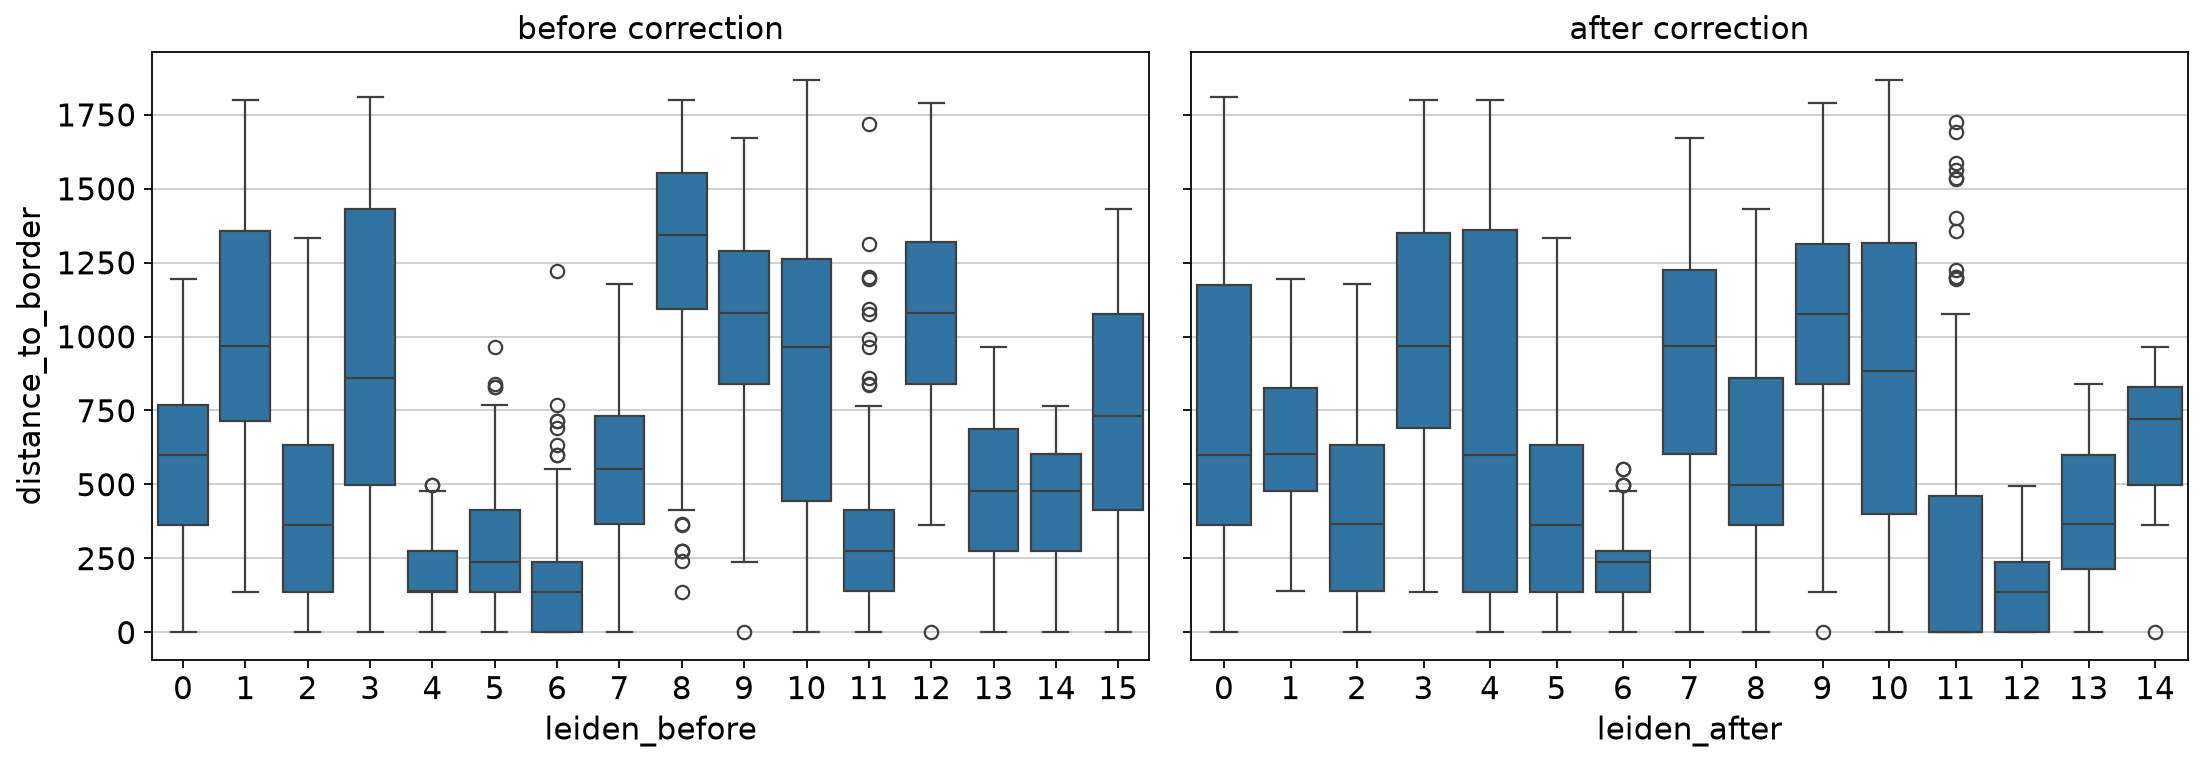

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
sns.boxplot(data=adata.obs, x="leiden_before", y="distance_to_border", ax=axes[0])
axes[0].set_title("before correction")
sns.boxplot(data=adata.obs, x="leiden_after", y="distance_to_border", ax=axes[1])
axes[1].set_title("after correction")
plt.tight_layout()
plt.savefig(OUT_DIR / "distance_by_cluster_boxplot.svg")
plt.show()